<center>
<h1> TP-Projet d'optimisation numérique </h1>
<h1> Algorithme des régions de confiance </h1>
</center>

# Régions de confiance avec Pas de Cauchy 

## Implémentation 

1. Coder l'algorithme du pas de Cauchy dans le fichier `src/cauchy.jl`). La spécification de cet algorithme est donnée dans le fichier.
2. Ecrire des tests exhaustifs (qui testent tous les cas de figure possibles) pour votre algorithme du pas de Cauchy. Vous remplirez pour cela le fichier `test/tester_cauchy.jl` sur le modèle des autres fichiers de tests et vous exécuterez dans la cellule de code ci-après ces tests.

In [14]:
include("../src/cauchy.jl")         # votre algorithme
include("../test/tester_cauchy.jl") # la fonction pour tester votre algorithme

tester_cauchy(cauchy); # tester l'algorithme

Test Summary: | Pass  Total  Time
Pas de Cauchy |    4      4  0.0s


3. Coder l'algorithme des régions de confiance (fichier `src/regions_de_confiance.jl`). Sa spécification est donnée dans le fichier.
4. Vérifier que les tests ci-dessous passent.

In [15]:
include("../src/regions_de_confiance.jl")
include("../test/tester_rc_cauchy.jl")

afficher = false # si true, alors affiche les résultats des algorithmes

tester_rc_cauchy(regions_de_confiance, afficher);

Affichage des résultats des algorithmes : false

Test Summary:        | Pass  Total  Time
RC et pas de Cauchy  |   15     15  0.5s


## Interprétation

<!-- Pour ces questions, des représentations graphiques sont attendues pour corroborer vos réponses. -->

1. Soit la fonction $f_1 \colon \mathbb{R}^3 \to \mathbb{R}$ définie par
$$
    f_1(x_1,x_2, x_3) = 2 (x_1 +x_2 + x_3 -3)^2 + (x_1-x_2)^2 + (x_2 - x_3)^2
$$
Quelle relation lie la fonction $f_1$ et son modèle de Taylor à l’ordre 2 ? Comparer alors les performances de l'algorithme de Newton et celui des régions de confiance avec le pas de Cauchy sur cette fonction.

$f_1$ est une fonction quadratique, donc son modèle de Taylor à l'ordre 2 lui est égal. Newton converge donc en une itération (cf [newton.ipynb](./newton.ipynb)).
L'algorithme du pas de Cauchy converge petit-à-petit. C'est-à-dire que le nombre d'itérations augmente quand $x_0$ s'éloigne de la solution.

-------------------------------------------------------------------------
Résultats de : Régions de confiance - Cauchy appliqué à f1:
  * x0       = [0, 0, 0]
  * x_sol    = [1.0, 1.0, 1.0]
  * f(x_sol) = 0.0
  * nb_iters = 1
  * flag     = 0
  * solution = [1, 1, 1]
-------------------------------------------------------------------------
Résultats de : Newton appliqué à f1:
  * x0       = [0, 0, 0]
  * x_sol    = [1.0, 1.0, 0.9999999999999999]
  * f(x_sol) = 1.232595164407831e-32
  * nb_iters = 1
  * flag     = 0
  * solution = [1, 1, 1]


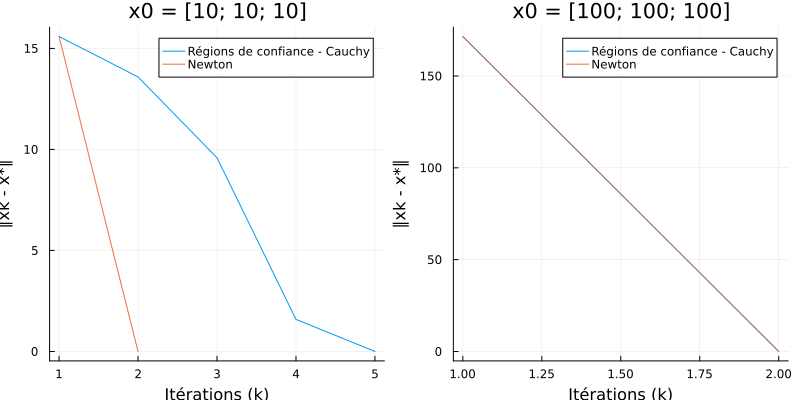

In [16]:
using Plots
include("../src/regions_de_confiance.jl")
include("../src/newton.jl")

# Fonction f1
# -----------
f1(x) = 2 * (x[1] + x[2] + x[3] - 3)^2 + (x[1] - x[2])^2 + (x[2] - x[3])^2
gradf1(x) = [4 * (x[1] + x[2] + x[3] - 3) + 2 * (x[1] - x[2]); # dérivée /x1
              4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[1] - x[2]) + 2 * (x[2] - x[3]); # dérivée /x2
              4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[2] - x[3])] # dérivée /x3
hessf1(x) = [6 2 4; 2 8 2; 4 2 6]
solution = [1; 1; 1]

x0s = [[0; 0; 0], [10; 10; 10], [100; 100; 100], [1000; 1000; 1000]]
nx0 = length(x0s)
height = 400
width = 400 * nx0
layoutx0 = (1, nx0)
sizex0 = (width, height)

x0 = [0; 0; 0]
# avec régions de confiance (pas de Cauchy)
x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, algo_pas="cauchy")
afficher_resultats("Régions de confiance - Cauchy", "f1", x0, x_sol, f_sol, flag, nb_iters, solution)
# avec Newton
x_sol, f_sol, flag, nb_iters, xs = newton(f1, gradf1, hessf1, x0)
afficher_resultats("Newton", "f1", x0, x_sol, f_sol, flag, nb_iters, solution)

x0 = [10; 10; 10]
# avec régions de confiance (pas de Cauchy)
x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, algo_pas="cauchy")
norm_diff_rc = [norm(x - solution) for x in xs]
# avec Newton
x_sol, f_sol, flag, nb_iters, xs = newton(f1, gradf1, hessf1, x0)
norm_diff_newton = [norm(x - solution) for x in xs]
p1 = plot(norm_diff_rc, label="Régions de confiance - Cauchy", title="x0 = [10; 10; 10]", xlabel="Itérations (k)", ylabel="∥xk - x*∥")
plot!(p1, norm_diff_newton, label="Newton")

x0 = [100; 100; 100]
# avec régions de confiance (pas de Cauchy)
x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, algo_pas="cauchy")
# avec Newton
x_sol, f_sol, flag, nb_iters, xs = newton(f1, gradf1, hessf1, x0)
p2 = plot([norm(x - solution) for x in xs], label="Régions de confiance - Cauchy", title="x0 = [100; 100; 100]", xlabel="Itérations (k)", ylabel="∥xk - x*∥")
plot!(p2, [norm(x - solution) for x in xs], label="Newton")

p = plot(p1, p2, layout=(1,2), size=(800, 400))
display(p)

2. Le rayon initial de la région de confiance est un paramètre important dans l’analyse de la performance de l’algorithme. Sur quel(s) autre(s) paramètre(s) peut-on jouer pour essayer d’améliorer cette performance ? Étudier l’influence d’au moins deux de ces paramètres. Pour cela vous ferez des tests numériques et donnerez les résultats sous forme de tableaux et de graphiques.

Lorsque $x_0$ est proche de la solution exacte, augmenter $\Delta_0$ permet de réduire drastiquement le nombre d'itérations. Lorque $x_0$ est plus loin de la solution exacte, $\Delta_0$ donne seulement une petite "avance" mais l'algorithme augmente rapidement le rayon pour converger plus rapidement.


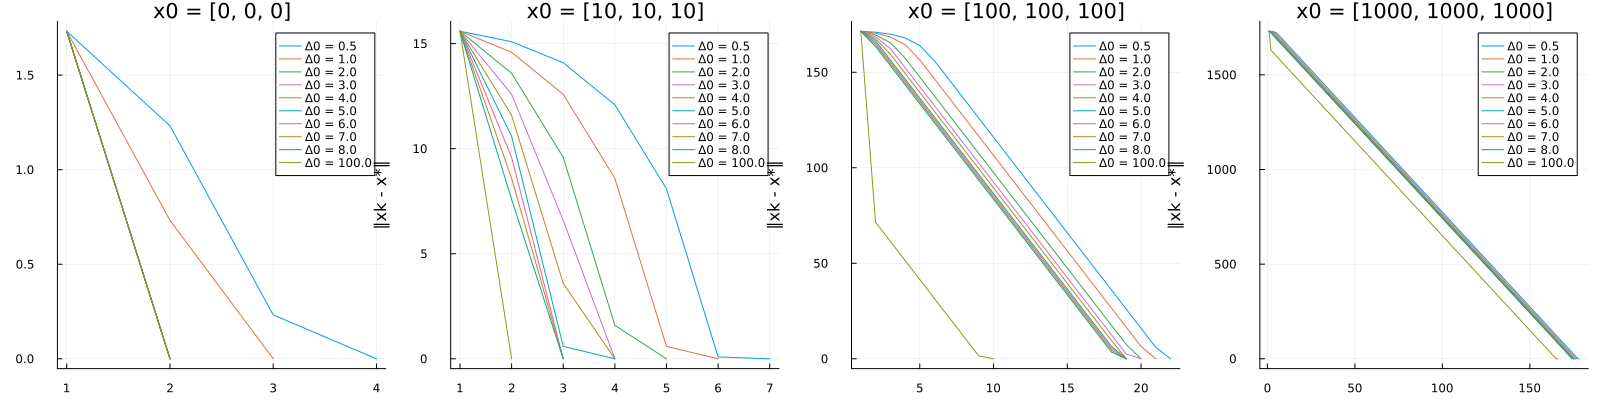

In [17]:
# Influence de Δ0 sur la convergence
p0s = []
for (i, x0) in enumerate(x0s)
	p1 = plot(title = "x0 = $x0", xlabel = "Itérations (k)", ylabel = "∥xk - x*∥")
	for Δ0 in [0.5; 1; 2; 3; 4; 5; 6; 7; 8; 100]
		x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, Δ0 = Δ0, algo_pas = "cauchy")
		plot!(p1, [norm(x - solution) for x in xs], label = "Δ0 = $Δ0")
	end
	p0s = push!(p0s, p1)
end
p0 = plot(p0s..., layout = layoutx0, size = sizex0, suptitle = "Influence de Δ0 sur la convergence")
display(p0)



Lorsque $x_0$ est proche de la solution exacte, augmenter $\Delta_\text{max}$ ne change presque rien. En effet, ce maximum n'est jamais atteint car l'algorithme n'a pas à faire de grands pas. Lorsque $x_0$ est plus loin de la solution exacte, l'influence de $\Delta_\text{max}$ est plus importante. En effet, l'algorithme peut faire de grands pas pour converger plus rapidement.

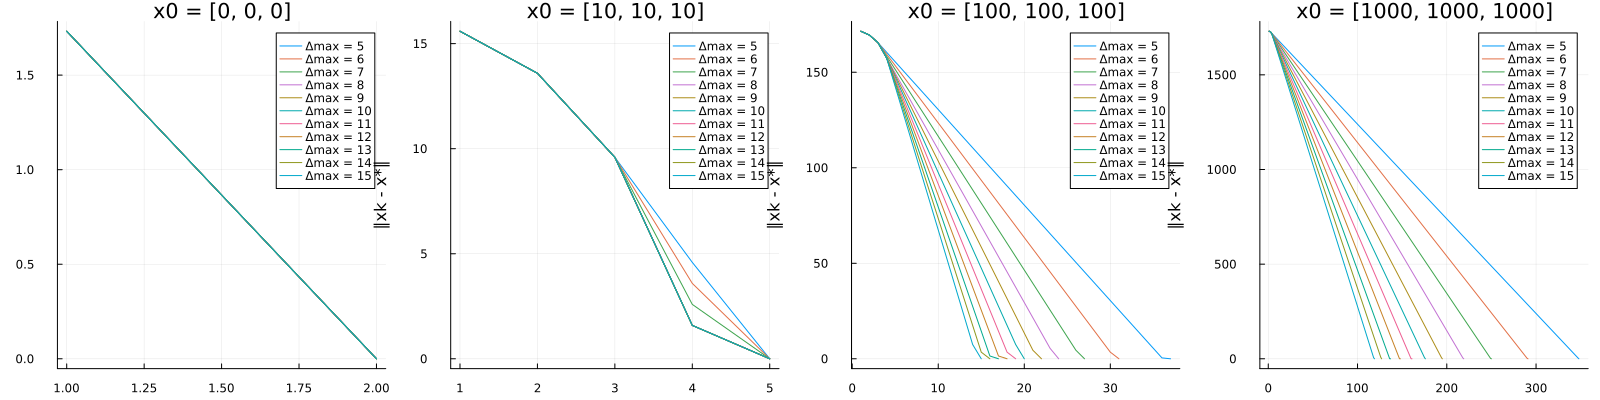

In [18]:
# Influence de Δmax sur la convergence
pmaxs = []
for (i, x0) in enumerate(x0s)
	p2 = plot(title = "x0 = $x0", xlabel = "Itérations (k)", ylabel = "∥xk - x*∥")
	for Δmax in [5:15;]
		x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, Δmax = Δmax, algo_pas = "cauchy")
		plot!(p2, [norm(x - solution) for x in xs], label = "Δmax = $Δmax")
	end
	pmaxs = push!(pmaxs, p2)
end
pmax = plot(pmaxs..., layout = layoutx0, size = sizex0, suptitle = "Influence de Δmax sur la convergence")
display(pmax)


$\gamma_1$ est le facteur de réduction de la région de confiance. Il doit être inférieur à $1$. Il n'a visiblement pas beaucoup d'influence.

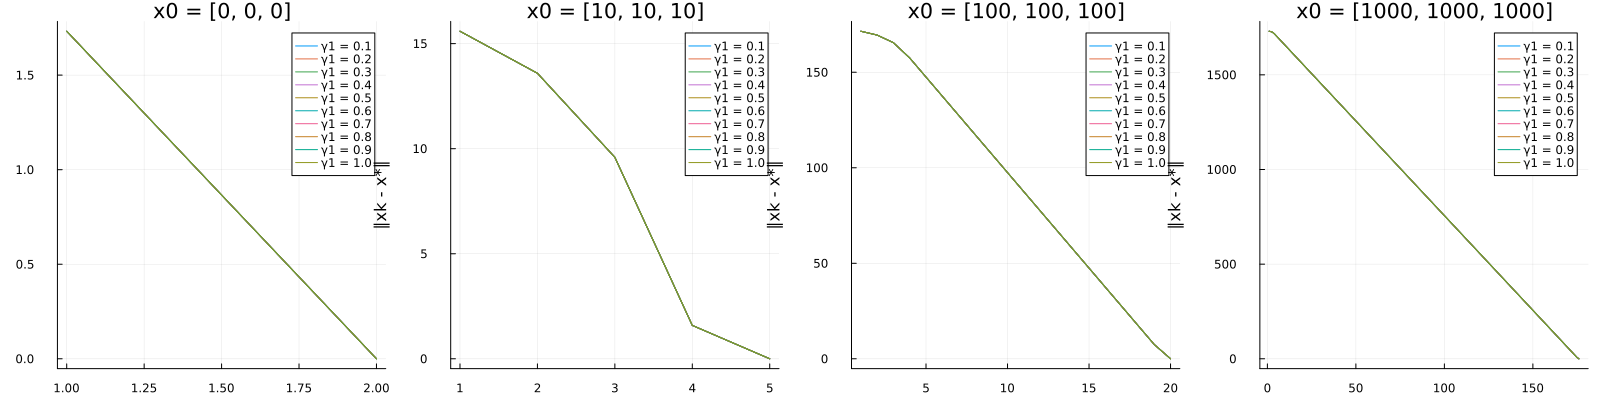

In [19]:
# Influence de γ1 sur la convergence
pγ1s = []
for (i, x0) in enumerate(x0s)
	p2 = plot(title = "x0 = $x0", xlabel = "Itérations (k)", ylabel = "∥xk - x*∥")
	for γ1 in [0.1; 0.2; 0.3; 0.4; 0.5; 0.6; 0.7; 0.8; 0.9; 1]
		x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, γ1 = γ1, algo_pas = "cauchy")
		plot!(p2, [norm(x - solution) for x in xs], label = "γ1 = $γ1")
	end
	pγ1s = push!(pγ1s, p2)
end
pγ1 = plot(pγ1s..., layout = layoutx0, size = sizex0, suptitle = "Influence de γ1 sur la convergence")
display(pγ1)


$\gamma_2$ est le le facteur d'augmentation de la région de confiance. Il doit être supérieur à $1$. Plus il est grand, plus l'algorithme va pouvoir augmenter la région de confiance d'une itération à l'autre. Son impact n'est pas flagrant quant à la convergence de l'algorithme. On remarque seulement une converge légèrement plus rapide lorsque $\gamma_2$ est grand.

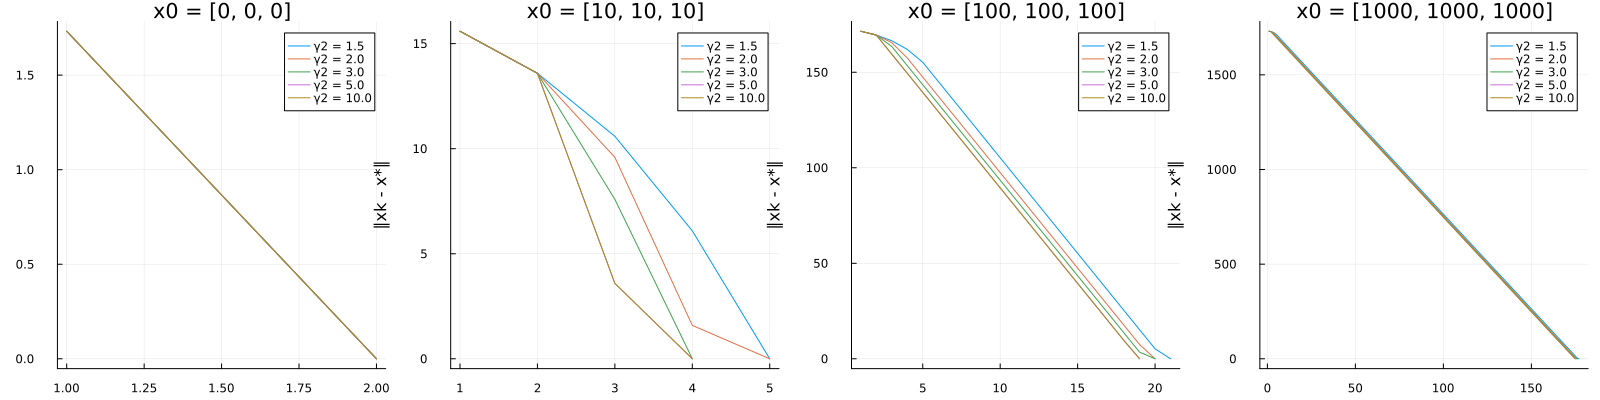

In [20]:
# Influence de γ2 sur la convergence
pγ2s = []
for (i, x0) in enumerate(x0s)
	p2 = plot(title = "x0 = $x0", xlabel = "Itérations (k)", ylabel = "∥xk - x*∥")
	for γ2 in [1.5; 2; 3; 5; 10]
		x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, γ2 = γ2, algo_pas = "cauchy")
		plot!(p2, [norm(x - solution) for x in xs], label = "γ2 = $γ2")
	end
	pγ2s = push!(pγ2s, p2)
end
pγ2 = plot(pγ2s..., layout = layoutx0, size = sizex0, suptitle = "Influence de γ2 sur la convergence")
display(pγ2)


$\eta_1$ est le seuil pour le rétrécissement de la région de confiance. Il doit être inférieur à $\eta_2$. Il est également le seuil de mise-à-jour de l'itéré $x_k$. Si $\eta_1$ est choisi trop grand, l'itéré ne sera jamais mis à jour et la région de confiance souvent réduite.

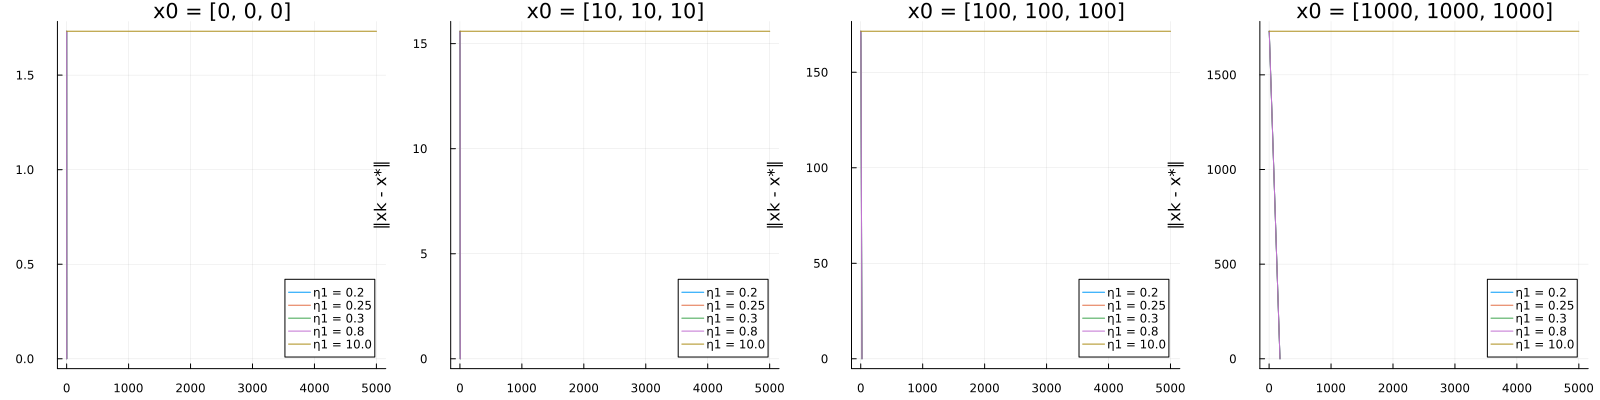

In [21]:
# Influence de η1 sur la convergence
pη1s = []
for (i, x0) in enumerate(x0s)
	p2 = plot(title = "x0 = $x0", xlabel = "Itérations (k)", ylabel = "∥xk - x*∥")
	for η1 in [0.2;0.25;0.3;0.8;10]
		x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, η1 = η1, algo_pas = "cauchy")
		plot!(p2, [norm(x - solution) for x in xs], label = "η1 = $η1")
	end
	pη1s = push!(pη1s, p2)
end
pη1 = plot(pη1s..., layout = layoutx0, size = sizex0, suptitle = "Influence de η1 sur la convergence")
display(pη1)


$\eta_2$ est le seuil pour l'agrandissement de la taille de la région de confiance. Il doit être supérieur à $\eta_1$. Plus il est grand, plus il est rare qu'elle soit aggrandie. Il "ralenti" donc la progression de l'algorithme lorsqu'il est grand. Similairement à $\Delta_\text{max}$, son influence est plus importante lorsque $x_0$ est loin de la solution exacte.

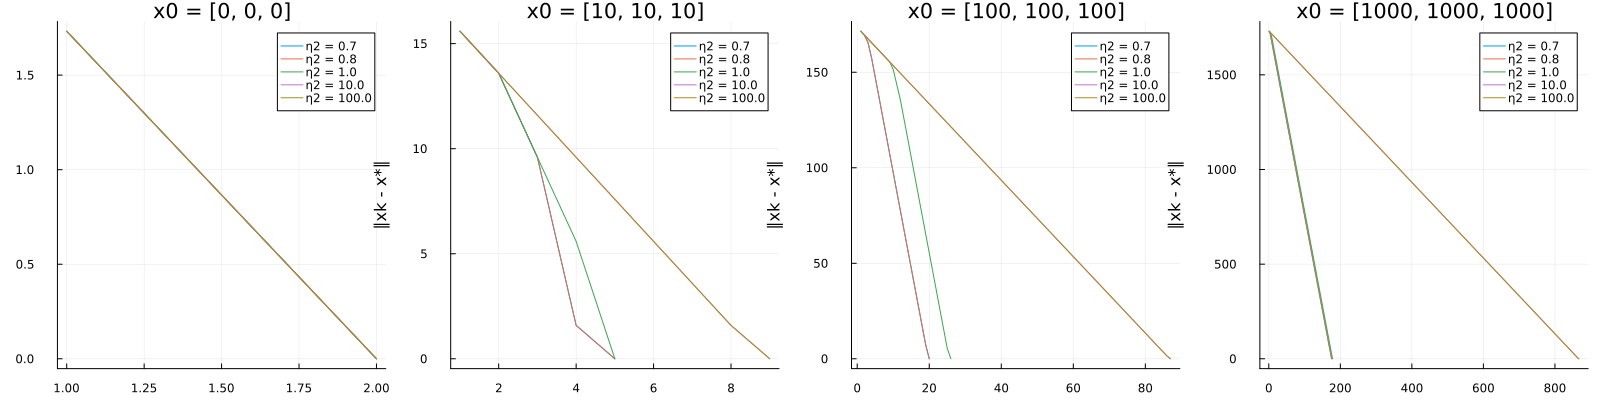

In [22]:
# Influence de η2 sur la convergence
pη2s = []
for (i, x0) in enumerate(x0s)
	p2 = plot(title = "x0 = $x0", xlabel = "Itérations (k)", ylabel = "∥xk - x*∥")
	for η2 in [0.7; 0.8; 1;10;100]
		x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, η2 = η2, algo_pas = "cauchy")
		plot!(p2, [norm(x - solution) for x in xs], label = "η2 = $η2")
	end
	pη2s = push!(pη2s, p2)
end
pη2 = plot(pη2s..., layout = layoutx0, size = sizex0, suptitle = "Influence de η2 sur la convergence")
display(pη2)


# Régions de confiance avec gradient conjugué tronqué

## Implémentation 

1. Implémenter l’algorithme du gradient conjugué tronqué (fichier `src/gct.jl`). Sa spécification est dans le fichier.
2. Vérifier que les tests ci-dessous passent.

In [23]:
include("../src/gct.jl")
include("../test/tester_gct.jl")

tester_gct(gct);

Test Summary:             | Pass  Total  Time
Gradient conjugué tronqué |    9      9  0.0s


3. Intégrer l’algorithme du gradient conjugué tronqué dans le code des régions de confiance.
4. Vérifier que les tests ci-dessous passent.

In [24]:
include("../src/regions_de_confiance.jl")
include("../test/tester_rc_gct.jl")

afficher = false # si true, alors affiche les résultats des algorithmes

tester_rc_gct(regions_de_confiance, afficher);

Affichage des résultats des algorithmes : false

Test Summary: | Pass  Total  Time
RC et gct     |   15     15  0.6s


## Interprétation  

Nous proposons de comparer l'utilisation du pas de Cauchy avec celle du gradient conjugué tronqué dans l'algorithme des régions de confiance.

**Remarques.**
* Nous vous demandons de réaliser des expérimentations numériques pour les comparaisons demandées ci-après.
* Vous devez utiliser l'argument optionnel `max_iter_gct` et la sortie `xs` de l'algorithme des régions de confiance.
* Vous pouvez comparer l'écart en norme entre les itérés de l'algorithme et la solution du problème.
* Vous trouverez des choses utiles dans le fichier `test/fonctions_de_tests.jl`.

1. Comparer dans le cas où l'on force le gradient conjugué tronqué à ne faire qu'une seule itération. Que remarquez vous ?

Lorsdque l'on force le CGT à faire une seule itération, on obtient des $x_s$ semblables à ceux obtenus avec l'algorithme de Newton.


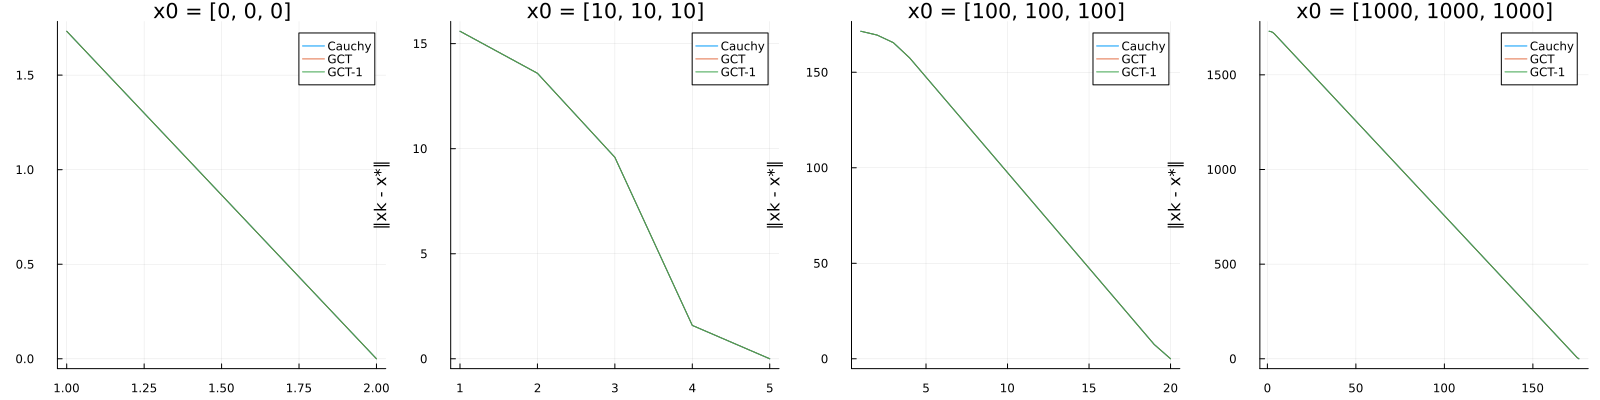

In [27]:
ps = []
for (i, x0) in enumerate(x0s)
	p = plot(title = "x0 = $x0", xlabel = "Itérations (k)", ylabel = "∥xk - x*∥")

	# pas de Cauchy
	x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, algo_pas = "cauchy")
	plot!(p, [norm(x - solution) for x in xs], label = "Cauchy")
    
    # GCT
    x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, algo_pas = "gct")
    plot!(p, [norm(x - solution) for x in xs], label = "GCT")

	# CGT-1
	x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, algo_pas = "gct", max_iter_gct = 1)
    plot!(p, [norm(x - solution) for x in xs], label = "GCT-1")
    p = push!(ps, p)
end

ptot = plot(ps..., layout = layoutx0, size = sizex0, suptitle = "Comparaison pas de Cauchy et GCT")
display(ptot)



2. Comparer dans le cas général. Que remarquez vous ?

TODO


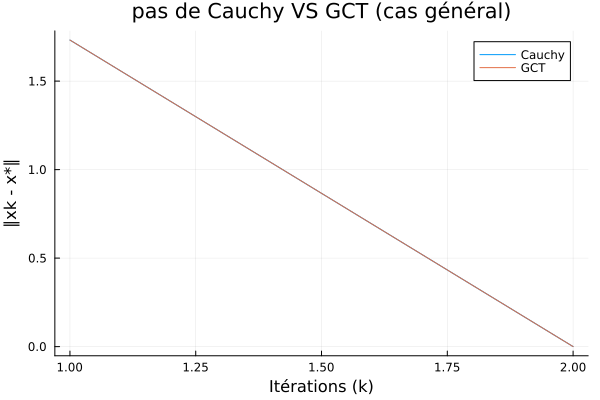

In [26]:
x0 = [0; 0; 0]
p = plot(ylabel = "∥xk - x*∥", xlabel = "Itérations (k)", title = "pas de Cauchy VS GCT (cas général)")
# pas de Cauchy
x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, algo_pas = "cauchy")
plot!(p, [norm(x - solution) for x in xs], label = "Cauchy")

# CGT
x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(f1, gradf1, hessf1, x0, algo_pas = "gct")
plot!(p, [norm(x - solution) for x in xs], label = "GCT")

display(p)



3. Quels sont les avantages et inconvénients des deux approches ?

TODO